<a href="https://colab.research.google.com/github/Monsoon886-cyb/ryokou/blob/master/Logistic_Regression_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [198]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [217]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples = 500, n_features = 2, n_informative = 1 , n_redundant = 0, n_classes = 2 , n_clusters_per_class = 1, random_state = 41, hypercube = False, class_sep = 20)

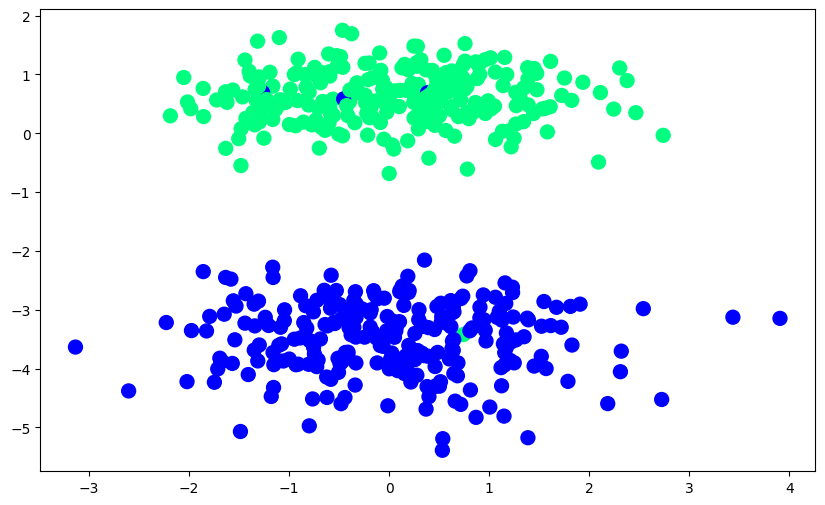

In [218]:
plt.figure(figsize = (10,6))
plt.scatter(X[:,0],X[:,1],c=y, cmap = 'winter',s=100)

##Logistic Regression from Sklearn

In [219]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [220]:
lor = LogisticRegression(penalty= None, solver ='sag')
lor.fit(X_train,y_train)

LogisticRegression(penalty=None, solver='sag')

In [221]:
lor.predict(X_test)

array([0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [222]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [223]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m1*x_input1 + b1

##Logisstic regression from scratch

In [224]:
class Barbatos:
  def __init__(self, lr=0.1, epochs=1000):
    self.epochs = epochs
    self.lr = lr
    self.coeff = None
    self.intercept = None

  def sigmoid(self, z):
    return 1/(1+ np.exp(-z))

  def awake(self, X, y):
    X = np.insert(X, 0, 1, axis = 1)
    weights = np.ones(X.shape[1])

    for i in range(self.epochs):
      y_hat = self.sigmoid(np.dot(X, weights))
      weights = weights + self.lr*(np.dot((y-y_hat),X)/X.shape[0])

    self.coeff = weights[1:]
    self.intercept = weights[0]

    return self.coeff, self.intercept

  def sento_mode(self, X, return_prob = False):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.insert(self.coeff, 0 , self.intercept)
    probs = self.sigmoid(np.dot(X, weights))

    if return_prob:
      probs = probs*100
      prob_percent = np.char.add(np.char.mod('%.2f', probs),'%')
      return prob_percent

    return (probs>=0.5).astype(int)

In [246]:
brb = Barbatos(epochs= 1000, lr = 0.5)

In [247]:
coeff, intercept = brb.awake(X_train,y_train)

In [248]:
brb.sento_mode(X_test )

array([0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [249]:
brb.sento_mode(X_test,return_prob = True )

array(['0.37%', '0.33%', '99.36%', '0.16%', '99.85%', '0.20%', '0.07%',
       '99.13%', '99.49%', '98.95%', '99.64%', '0.01%', '99.72%', '0.46%',
       '0.06%', '0.02%', '0.04%', '1.37%', '97.58%', '93.39%', '0.05%',
       '0.01%', '2.20%', '0.05%', '99.73%', '97.67%', '99.83%', '99.32%',
       '0.24%', '0.57%', '0.84%', '2.60%', '98.70%', '2.32%', '0.28%',
       '0.03%', '0.19%', '96.03%', '0.43%', '98.17%', '99.80%', '0.07%',
       '99.42%', '0.56%', '0.06%', '0.01%', '0.88%', '99.56%', '97.19%',
       '0.14%', '99.69%', '0.08%', '0.44%', '99.67%', '0.58%', '0.38%',
       '0.37%', '99.85%', '0.02%', '98.45%', '99.38%', '99.80%', '0.29%',
       '97.18%', '99.57%', '0.18%', '91.82%', '99.04%', '96.71%', '0.03%',
       '99.60%', '0.27%', '0.06%', '88.14%', '99.79%', '98.65%', '98.59%',
       '1.77%', '99.73%', '0.06%', '99.61%', '0.35%', '0.12%', '99.52%',
       '0.06%', '91.41%', '1.30%', '1.06%', '0.12%', '99.52%', '99.46%',
       '0.10%', '0.31%', '96.32%', '99.43%', '97

In [250]:
m = -(coeff[0]/coeff[1])
b = -(intercept/coeff[1])

In [251]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

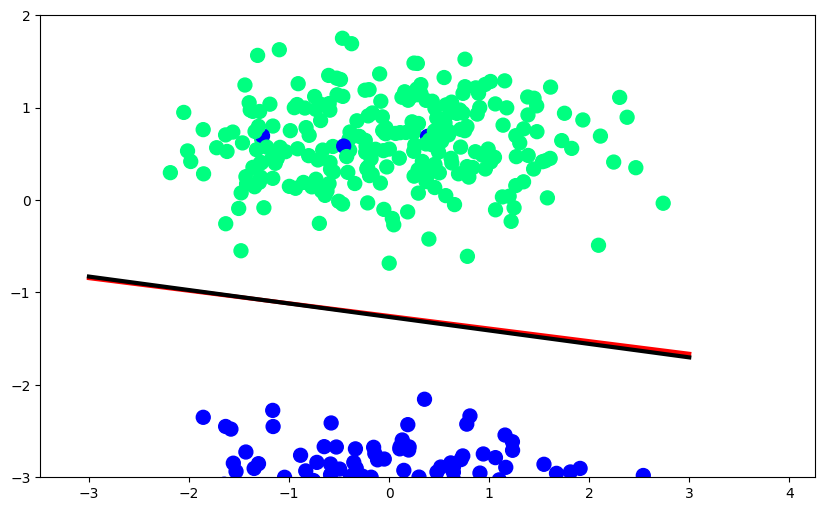

In [252]:
plt.figure(figsize = (10,6))
plt.plot(x_input,y_input,color='red',linewidth = 3)
plt.plot(x_input1,y_input1,color='black',linewidth = 3)
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=100)
plt.ylim(-3,2)